<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/09_Phase_Estimation/QPE_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Quantum Phase Estimation (QPE)

This notebook implements the Quantum Phase Estimation algorithm. QPE is one of the most important subroutines in quantum computing, serving as the central building block for Shor's algorithm (factoring) and the HHL algorithm (solving linear systems of equations).

## The Problem

Given a unitary operator (a quantum gate) $U$ and its quantum state (eigenvector) $|\psi\rangle$, applying the gate to the state will only change its global phase. Mathematically, this is expressed as:

$$U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$$

Our goal is to figure out the exact value of $\theta$ (the phase). Classically, determining this eigenvalue for massive matrices is computationally intractable.

## The Quantum Solution

QPE utilizes a phenomenon called **Phase Kickback** alongside the **Quantum Fourier Transform (QFT)** to perfectly estimate $\theta$. The protocol requires two registers of qubits: a "counting" register to store the answer, and a "target" register to hold the eigenstate.

1. **Superposition:** We apply Hadamard gates to the counting register to put it into an equal superposition of all possible states.
2. **Controlled Unitaries:** We apply the unitary operator $U$ to the target register, controlled by the counting register. We do this in increasing powers of 2 ($U^1, U^2, U^4$, etc.). Because of phase kickback, the phase $\theta$ is "kicked" up into the amplitudes of the counting qubits.
3. **Inverse QFT:** The phase is now encoded in the Fourier basis. We apply an Inverse Quantum Fourier Transform (IQFT) to convert it back into the standard computational basis.
4. **Measurement:** We measure the counting register. The resulting binary string is the exact binary fraction of our phase $\theta$.

In the code below, we will estimate the phase of the **T-gate**. The T-gate applies a phase of $\frac{\pi}{4}$. Therefore, our target $\theta$ is exactly $\frac{1}{8}$ (or `0.125`).

---



In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=bb4d58a8662b3777178a3a23281424b1c66e5e89cb93cc3461e3251d7b6ce5fd
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- QPE Results ---
Target Gate: T-Gate
Measured Binary String: 001
Math: 1 / 2^3
Estimated Phase: 0.125

SUCCESS! The algorithm perfectly estimated the phase as 1/8 (0.125).


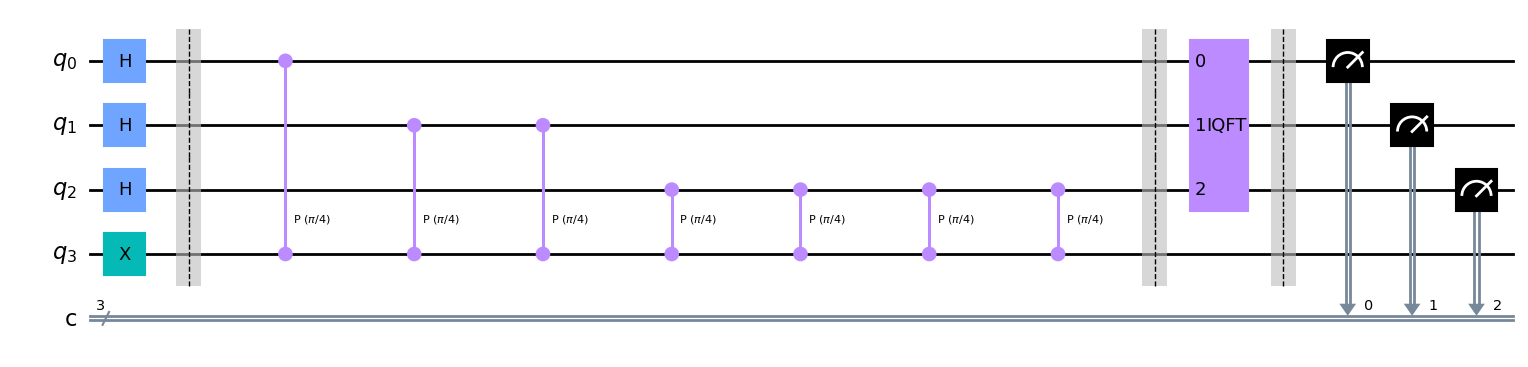

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
import math

def build_qpe_circuit():
    """Builds a QPE circuit using modern Qiskit 1.0+ compilation standards."""

    # We use 3 counting qubits and 1 target qubit.
    qc = QuantumCircuit(4, 3)

    # --- 1. State Preparation ---
    qc.x(3)
    qc.h([0, 1, 2])
    qc.barrier()

    # --- 2. Controlled Unitary Operations ---
    angle = math.pi / 4
    repetitions = 1

    for counting_qubit in range(3):
        for _ in range(repetitions):
            qc.cp(angle, counting_qubit, 3)
        repetitions *= 2

    qc.barrier()

    # --- 3. Inverse Quantum Fourier Transform (IQFT) ---
    # Using the modern QFTGate and taking its inverse
    iqft_gate = QFTGate(3).inverse()
    iqft_gate.name = "IQFT"

    # Append the abstract gate to our circuit
    qc.append(iqft_gate, [0, 1, 2])
    qc.barrier()

    # --- 4. Measurement ---
    qc.measure([0, 1, 2], [0, 1, 2])

    # --- 5. Transpilation and Execution ---
    simulator = AerSimulator()

    # CRITICAL STEP: Transpile the abstract circuit into simulator-native instructions
    compiled_qc = transpile(qc, simulator)

    # We run the COMPILED circuit, not the original
    job = simulator.run(compiled_qc, shots=1000)
    result = job.result()
    counts = result.get_counts(compiled_qc)

    # --- 6. Data Processing ---
    measured_binary = list(counts.keys())[0]
    decimal_value = int(measured_binary, 2)
    estimated_phase = decimal_value / (2 ** 3)

    print("--- QPE Results ---")
    print(f"Target Gate: T-Gate")
    print(f"Measured Binary String: {measured_binary}")
    print(f"Math: {decimal_value} / 2^3")
    print(f"Estimated Phase: {estimated_phase}")

    if estimated_phase == 0.125:
        print("\nSUCCESS! The algorithm perfectly estimated the phase as 1/8 (0.125).")

    # Draw the ORIGINAL un-compiled circuit to keep the schematic clean and readable
    display(qc.draw('mpl', style='clifford'))

# Run the algorithm
build_qpe_circuit()